<a href="https://colab.research.google.com/github/Jtuaz/Projects-Portfolio-/blob/main/Taxi_Demand_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Yellow: (3475226, 20)
Green: (48326, 21)
FHV: (1898108, 7)
Yellow Columns: Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')
Green Columns: Index(['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge',
       'total_amount', 'payment_type', 'trip_type', 'congestion_surcharg

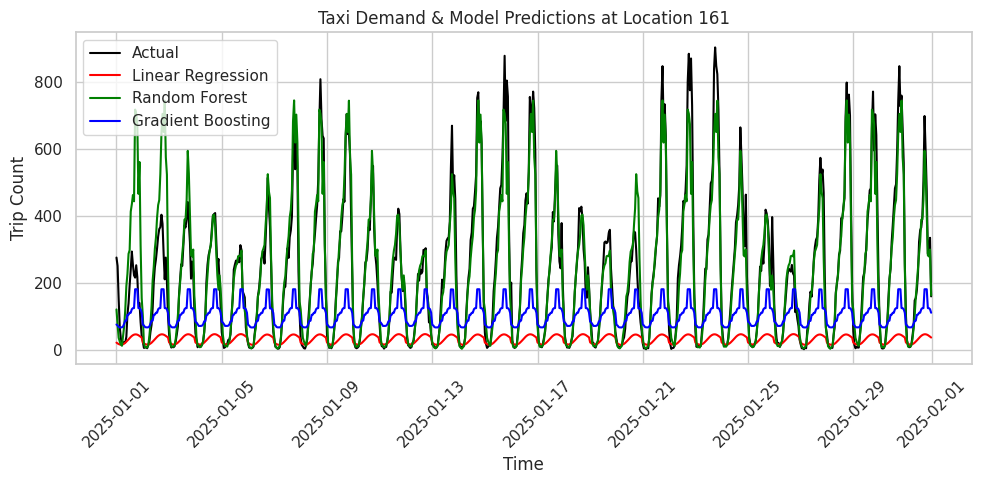

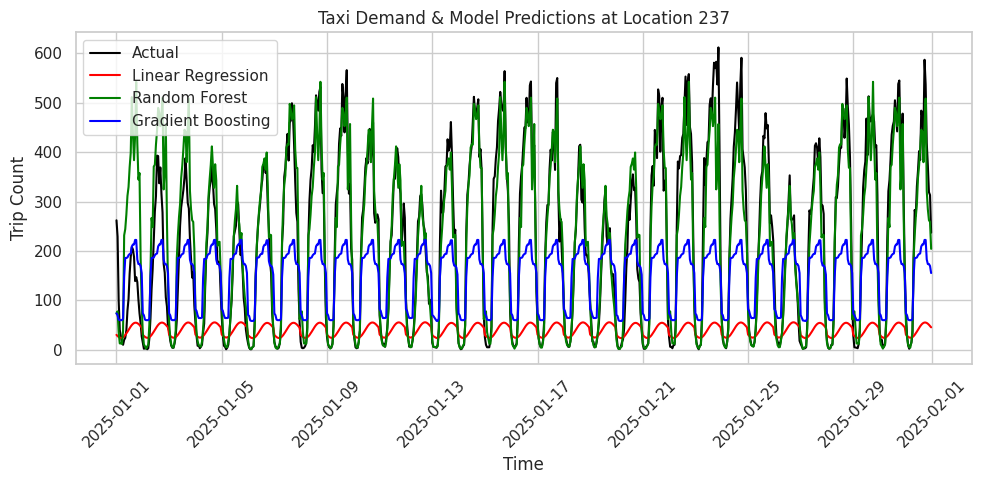

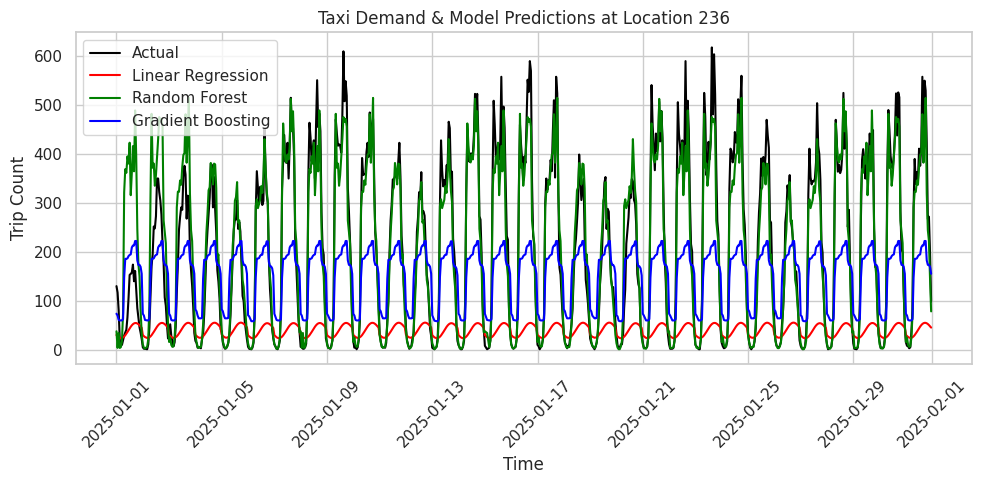

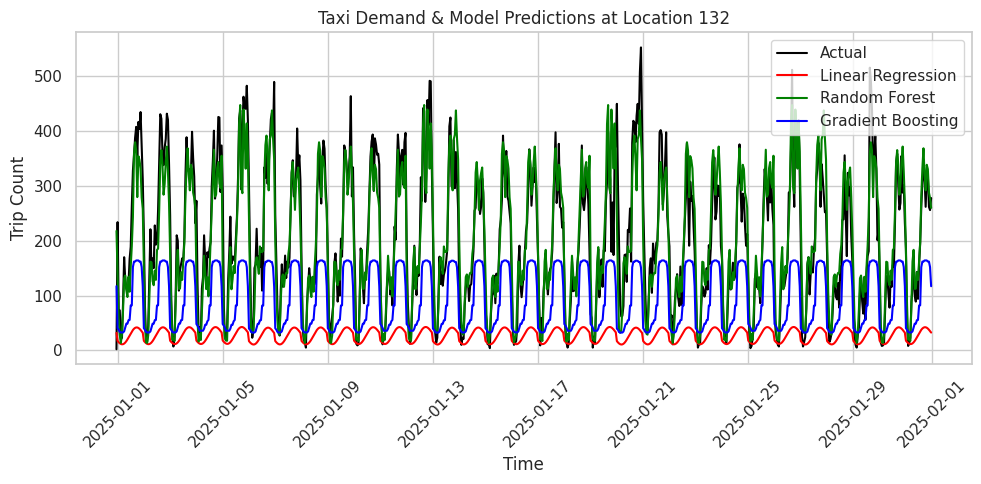

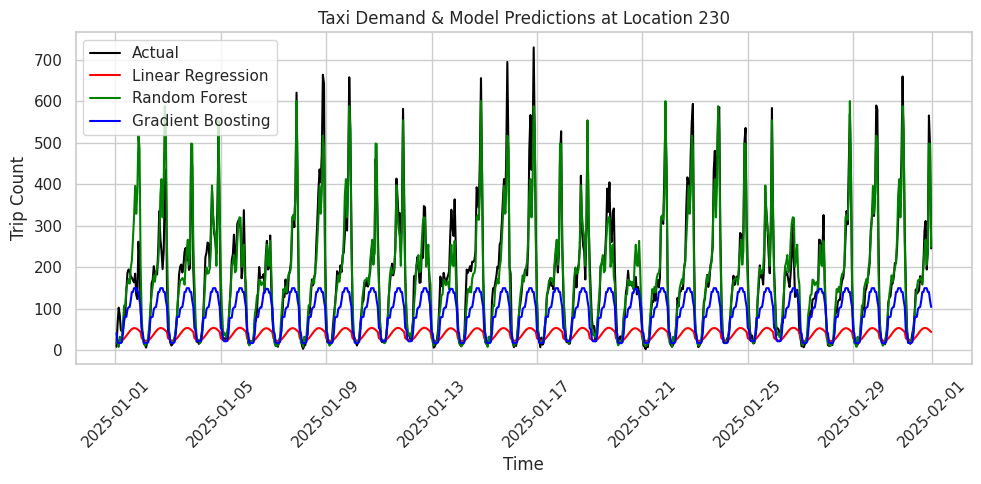

/tmp/ipykernel_2609/2732264335.py:203: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(ROOT_MEAN_SQUARED_ERROR_DICTIONARY.keys()), y=list(ROOT_MEAN_SQUARED_ERROR_DICTIONARY.values()), palette=['red', 'green', 'blue'])  # Plot error bars


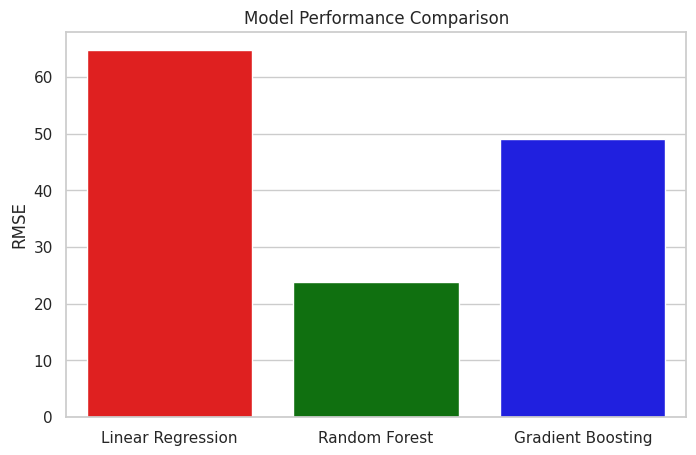


Elbow Method Values:
k	Inertia
2	2343.95
3	1693.39
4	1218.08
5	1006.98
6	804.62
7	702.40
8	638.52
9	568.96
10	495.08


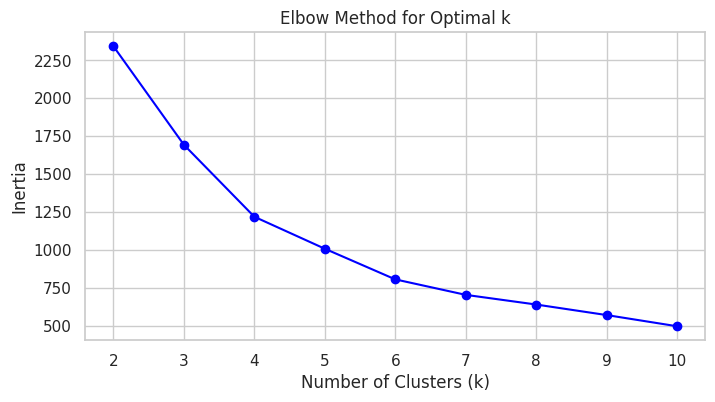

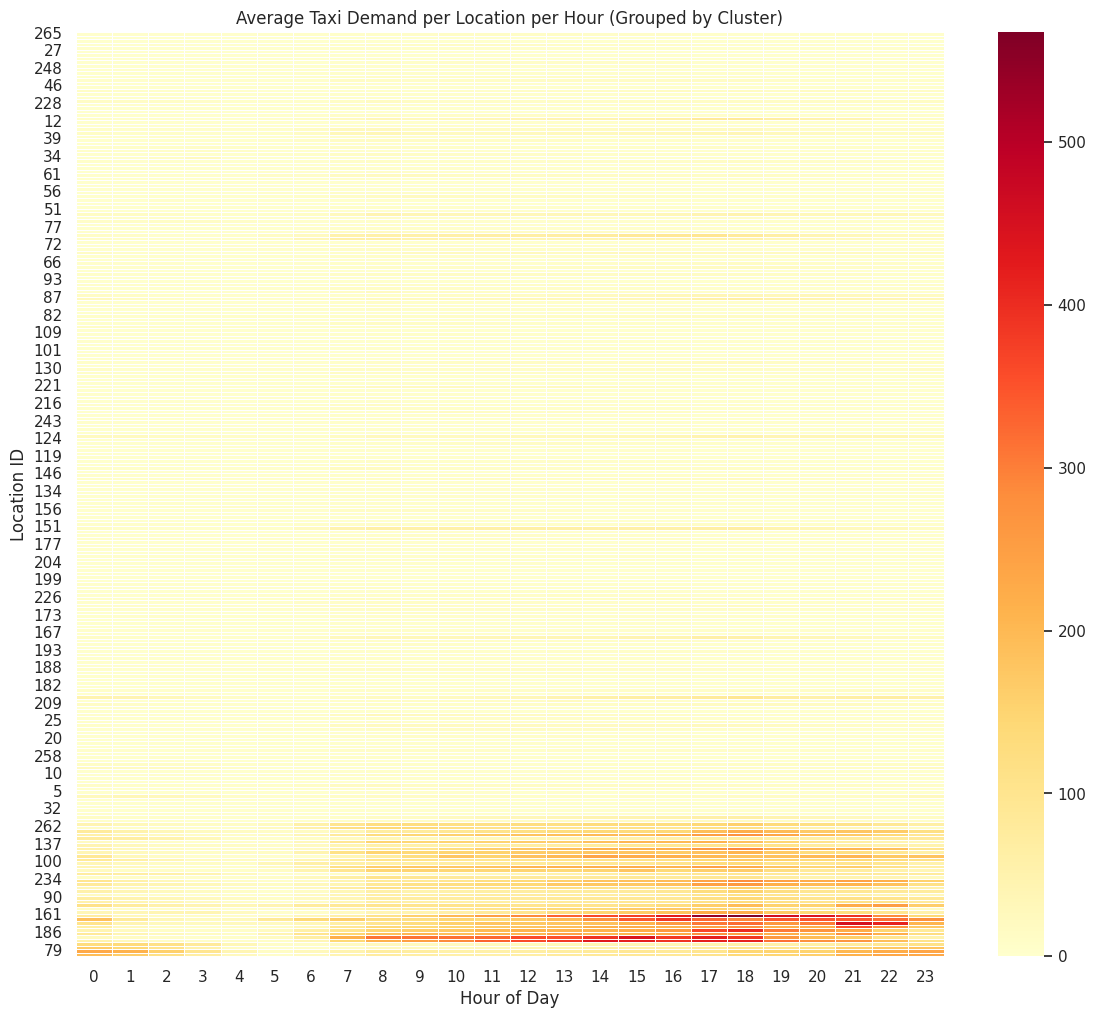


Cluster assignment for top locations:
hour  location_id  cluster
0               1        0
1               2        0
2               3        0
3               4        0
4               5        0
..            ...      ...
257           261        0
258           262        1
259           263        1
260           264        0
261           265        0

[262 rows x 2 columns]

POWERPOINT PREDICTION TABLE (TOP 20 ROWS)
    location_id  hour  day_of_week      hour_sin      hour_cos  \
0           107    17            4 -9.659258e-01 -2.588190e-01   
1            25     7            1  9.659258e-01 -2.588190e-01   
2            84    14            1 -5.000000e-01 -8.660254e-01   
3           229     9            0  7.071068e-01 -7.071068e-01   
4            49     9            6  7.071068e-01 -7.071068e-01   
5           121    15            3 -7.071068e-01 -7.071068e-01   
6           243     8            3  8.660254e-01 -5.000000e-01   
7            51    11            3  2.5881

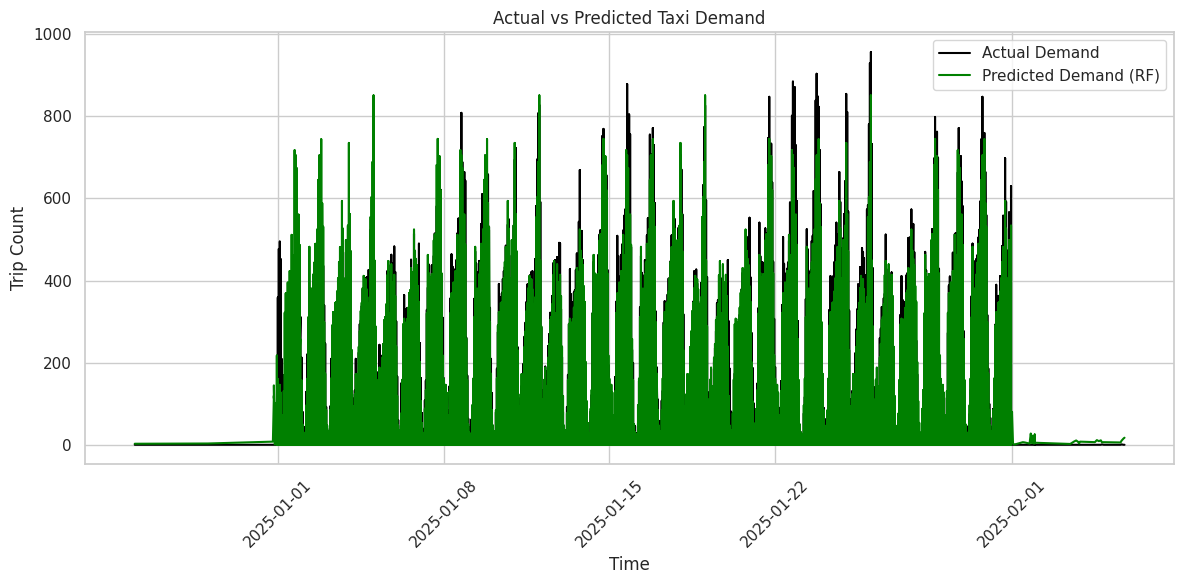

Export complete: taxi_time_bin_data.csv


In [8]:
# Install required engine libraries for Parquet file reading in Colab
!pip install -q pyarrow fastparquet scikit-learn matplotlib seaborn pandas numpy

from google.colab import drive
import os

# Mount Google Drive to access stored dataset files
drive.mount('/content/drive')

# Define base folder path inside Google Drive (Update to match your Drive folder structure)
BASE_DATASET_DIRECTORY_PATH = "/content/drive/MyDrive/"

# Verify directory exists
if not os.path.exists(BASE_DATASET_DIRECTORY_PATH):
    print(f"Warning: Directory '{BASE_DATASET_DIRECTORY_PATH}' not found.")
    print("Creating local directory '/content/data' as fallback...")
    BASE_DATASET_DIRECTORY_PATH = "/content/data"
    os.makedirs(BASE_DATASET_DIRECTORY_PATH, exist_ok=True)

# Imports for data manipulation, machine learning models, scaling, and visualization
import numpy as np  # Matrix and numerical operations
import pandas as pd  # Dataframe manipulation and parquet file parsing
import matplotlib.pyplot as plt  # Plotting and data visualization
import seaborn as sns  # Enhanced statistical data visualization
from sklearn.model_selection import train_test_split  # Dataset splitting utility
from sklearn.linear_model import LinearRegression  # Baseline linear regression algorithm
from sklearn.ensemble import RandomForestRegressor  # Ensemble random forest regressor
from sklearn.ensemble import GradientBoostingRegressor  # Gradient boosting regressor
from sklearn.preprocessing import StandardScaler  # Feature normalization scaler
from sklearn.cluster import KMeans  # K-Means clustering algorithm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score  # Evaluation metrics

# Read raw parquet datasets into individual DataFrames
YELLOW_TAXI_DATAFRAME = pd.read_parquet(os.path.join(BASE_DATASET_DIRECTORY_PATH, "yellow_tripdata_2025-01.parquet"))  # Read Yellow taxi dataset
GREEN_TAXI_DATAFRAME  = pd.read_parquet(os.path.join(BASE_DATASET_DIRECTORY_PATH, "green_tripdata_2025-01.parquet"))   # Read Green taxi dataset
FOR_HIRE_VEHICLE_DATAFRAME = pd.read_parquet(os.path.join(BASE_DATASET_DIRECTORY_PATH, "fhv_tripdata_2025-01.parquet"))  # Read FHV dataset

# Display initial record counts and column structures across all datasets
print("Yellow:", YELLOW_TAXI_DATAFRAME.shape)  # Output dimensions of yellow dataset
print("Green:", GREEN_TAXI_DATAFRAME.shape)    # Output dimensions of green dataset
print("FHV:", FOR_HIRE_VEHICLE_DATAFRAME.shape) # Output dimensions of FHV dataset
print("Yellow Columns:", YELLOW_TAXI_DATAFRAME.columns)
print("Green Columns:", GREEN_TAXI_DATAFRAME.columns)
print("FHV Columns:", FOR_HIRE_VEHICLE_DATAFRAME.columns)

# Standardize column headers across Yellow Taxi DataFrame
YELLOW_TAXI_DATAFRAME = YELLOW_TAXI_DATAFRAME.rename(columns={
    'tpep_pickup_datetime': 'pickup_datetime',
    'tpep_dropoff_datetime': 'dropoff_datetime',
    'PULocationID': 'location_id',
    'DOLocationID': 'dropoff_location_id'
})

# Standardize column headers across Green Taxi DataFrame
GREEN_TAXI_DATAFRAME = GREEN_TAXI_DATAFRAME.rename(columns={
    'lpep_pickup_datetime': 'pickup_datetime',
    'lpep_dropoff_datetime': 'dropoff_datetime',
    'PULocationID': 'location_id',
    'DOLocationID': 'dropoff_location_id'
})

# Standardize column headers across For-Hire Vehicle DataFrame
FOR_HIRE_VEHICLE_DATAFRAME = FOR_HIRE_VEHICLE_DATAFRAME.rename(columns={
    'PUlocationID': 'location_id',
    'DOlocationID': 'dropoff_location_id',
    'dropOff_datetime': 'dropoff_datetime'
})

# Filter DataFrames to retain only relevant modeling features
YELLOW_TAXI_DATAFRAME = YELLOW_TAXI_DATAFRAME[['pickup_datetime', 'location_id']]  # Keep essential yellow columns
GREEN_TAXI_DATAFRAME  = GREEN_TAXI_DATAFRAME[['pickup_datetime', 'location_id']]   # Keep essential green columns
FOR_HIRE_VEHICLE_DATAFRAME = FOR_HIRE_VEHICLE_DATAFRAME[['pickup_datetime', 'location_id']]  # Keep essential FHV columns

# Tag dataset source for classification tracking
YELLOW_TAXI_DATAFRAME['service'] = 'yellow'  # Label yellow trip rows
GREEN_TAXI_DATAFRAME['service'] = 'green'   # Label green trip rows
FOR_HIRE_VEHICLE_DATAFRAME['service'] = 'fhv'  # Label FHV trip rows

# Concatenate all taxi services into a single unified dataset
COMBINED_TAXI_DATAFRAME = pd.concat([YELLOW_TAXI_DATAFRAME, GREEN_TAXI_DATAFRAME, FOR_HIRE_VEHICLE_DATAFRAME], ignore_index=True)
print("\nCombined shape:", COMBINED_TAXI_DATAFRAME.shape)  # Display total row count
print(COMBINED_TAXI_DATAFRAME.head())  # Preview combined dataset top rows

# Parse timestamps and handle invalid entries
COMBINED_TAXI_DATAFRAME['pickup_datetime'] = pd.to_datetime(COMBINED_TAXI_DATAFRAME['pickup_datetime'], errors='coerce')  # Coerce unparseable dates to NaT
COMBINED_TAXI_DATAFRAME = COMBINED_TAXI_DATAFRAME.dropna(subset=['pickup_datetime', 'location_id'])  # Drop missing timestamp or location entries
COMBINED_TAXI_DATAFRAME['location_id'] = COMBINED_TAXI_DATAFRAME['location_id'].astype(int)  # Typecast location IDs to integers

# Extract time components for cyclical feature encoding
COMBINED_TAXI_DATAFRAME['hour'] = COMBINED_TAXI_DATAFRAME['pickup_datetime'].dt.hour  # Extract hour of day
COMBINED_TAXI_DATAFRAME['day_of_week'] = COMBINED_TAXI_DATAFRAME['pickup_datetime'].dt.dayofweek  # Extract day of week index
COMBINED_TAXI_DATAFRAME['hour_sin'] = np.sin(2 * np.pi * COMBINED_TAXI_DATAFRAME['hour'] / 24)  # Sine transformation for hourly seasonality
COMBINED_TAXI_DATAFRAME['hour_cos'] = np.cos(2 * np.pi * COMBINED_TAXI_DATAFRAME['hour'] / 24)  # Cosine transformation for hourly seasonality
COMBINED_TAXI_DATAFRAME['time_bin'] = COMBINED_TAXI_DATAFRAME['pickup_datetime'].dt.floor('h')  # Truncate timestamps to hourly intervals

# Aggregate total trips grouped by pickup location and hourly time bin
AGGREGATED_DEMAND_DATAFRAME = COMBINED_TAXI_DATAFRAME.groupby(['location_id', 'time_bin']).size().reset_index(name='trip_count')
print("\nAggregated Demand Head:")
print(AGGREGATED_DEMAND_DATAFRAME.head())  # Inspect aggregated demand table

# Re-extract temporal features post-aggregation
AGGREGATED_DEMAND_DATAFRAME['hour'] = AGGREGATED_DEMAND_DATAFRAME['time_bin'].dt.hour  # Hour of day feature
AGGREGATED_DEMAND_DATAFRAME['day_of_week'] = AGGREGATED_DEMAND_DATAFRAME['time_bin'].dt.dayofweek  # Day of week feature
AGGREGATED_DEMAND_DATAFRAME['hour_sin'] = np.sin(2 * np.pi * AGGREGATED_DEMAND_DATAFRAME['hour'] / 24)  # Sine encoded hour
AGGREGATED_DEMAND_DATAFRAME['hour_cos'] = np.cos(2 * np.pi * AGGREGATED_DEMAND_DATAFRAME['hour'] / 24)  # Cosine encoded hour

# Split features and target labels
FEATURE_MATRIX = AGGREGATED_DEMAND_DATAFRAME[['location_id', 'hour', 'day_of_week', 'hour_sin', 'hour_cos']]  # Input predictor matrix
TARGET_VECTOR = AGGREGATED_DEMAND_DATAFRAME['trip_count']  # Target variable to predict

# Split dataset into training and validation subsets
TRAIN_FEATURE_MATRIX, TEST_FEATURE_MATRIX, TRAIN_TARGET_VECTOR, TEST_TARGET_VECTOR = train_test_split(
    FEATURE_MATRIX, TARGET_VECTOR, test_size=0.2, random_state=42
)  # Perform 80/20 train-test split

# Linear Regression Model Training & Evaluation
LINEAR_REGRESSION_MODEL = LinearRegression()  # Instantiate Linear Regression model
LINEAR_REGRESSION_MODEL.fit(TRAIN_FEATURE_MATRIX, TRAIN_TARGET_VECTOR)  # Fit model on training data
PREDICTED_TARGET_LINEAR_REGRESSION = LINEAR_REGRESSION_MODEL.predict(TEST_FEATURE_MATRIX)  # Predict test set
ROOT_MEAN_SQUARED_ERROR_LINEAR_REGRESSION = mean_squared_error(TEST_TARGET_VECTOR, PREDICTED_TARGET_LINEAR_REGRESSION) ** 0.5  # Calculate RMSE
print("\nLinear Regression RMSE:", ROOT_MEAN_SQUARED_ERROR_LINEAR_REGRESSION)  # Print linear model error

# Random Forest Model Training & Evaluation
RANDOM_FOREST_MODEL = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)  # Enable n_jobs=-1 for faster execution in Colab
RANDOM_FOREST_MODEL.fit(TRAIN_FEATURE_MATRIX, TRAIN_TARGET_VECTOR)  # Fit model on training data
PREDICTED_TARGET_RANDOM_FOREST = RANDOM_FOREST_MODEL.predict(TEST_FEATURE_MATRIX)  # Predict test set
ROOT_MEAN_SQUARED_ERROR_RANDOM_FOREST = mean_squared_error(TEST_TARGET_VECTOR, PREDICTED_TARGET_RANDOM_FOREST) ** 0.5  # Calculate RMSE
print("Random Forest RMSE:", ROOT_MEAN_SQUARED_ERROR_RANDOM_FOREST)  # Print random forest error

# Gradient Boosting Model Training & Evaluation
GRADIENT_BOOSTING_MODEL = GradientBoostingRegressor(n_estimators=50, random_state=42)  # Instantiate Gradient Boosting Regressor
GRADIENT_BOOSTING_MODEL.fit(TRAIN_FEATURE_MATRIX, TRAIN_TARGET_VECTOR)  # Fit model on training data
PREDICTED_TARGET_GRADIENT_BOOSTING = GRADIENT_BOOSTING_MODEL.predict(TEST_FEATURE_MATRIX)  # Predict test set
ROOT_MEAN_SQUARED_ERROR_GRADIENT_BOOSTING = mean_squared_error(TEST_TARGET_VECTOR, PREDICTED_TARGET_GRADIENT_BOOSTING) ** 0.5  # Calculate RMSE
print("Gradient Boosting RMSE:", ROOT_MEAN_SQUARED_ERROR_GRADIENT_BOOSTING)  # Print gradient boosting error

# Print direct summary comparison of model RMSE metrics
print("\nModel Comparison:")
print("Linear Regression RMSE:", ROOT_MEAN_SQUARED_ERROR_LINEAR_REGRESSION)
print("Random Forest RMSE:", ROOT_MEAN_SQUARED_ERROR_RANDOM_FOREST)
print("Gradient Boosting RMSE:", ROOT_MEAN_SQUARED_ERROR_GRADIENT_BOOSTING)

# Helper function to compute and output comprehensive regression performance metrics
def EVALUATE_REGRESSION_MODEL(TRUE_TARGET_VALUES, PREDICTED_TARGET_VALUES, MODEL_NAME_STRING):
    CALCULATED_ROOT_MEAN_SQUARED_ERROR = mean_squared_error(TRUE_TARGET_VALUES, PREDICTED_TARGET_VALUES) ** 0.5  # Calculate RMSE
    CALCULATED_MEAN_ABSOLUTE_ERROR = mean_absolute_error(TRUE_TARGET_VALUES, PREDICTED_TARGET_VALUES)  # Calculate MAE
    CALCULATED_R2_SCORE = r2_score(TRUE_TARGET_VALUES, PREDICTED_TARGET_VALUES)  # Calculate R² score
    print(f"\n{MODEL_NAME_STRING} Performance:")
    print(f"RMSE: {CALCULATED_ROOT_MEAN_SQUARED_ERROR:.2f}, MAE: {CALCULATED_MEAN_ABSOLUTE_ERROR:.2f}, R²: {CALCULATED_R2_SCORE:.4f}")
    return CALCULATED_ROOT_MEAN_SQUARED_ERROR, CALCULATED_MEAN_ABSOLUTE_ERROR, CALCULATED_R2_SCORE

# Compute complete metric profiles for all three models
METRICS_LINEAR_REGRESSION = EVALUATE_REGRESSION_MODEL(TEST_TARGET_VECTOR, PREDICTED_TARGET_LINEAR_REGRESSION, "Linear Regression")
METRICS_RANDOM_FOREST = EVALUATE_REGRESSION_MODEL(TEST_TARGET_VECTOR, PREDICTED_TARGET_RANDOM_FOREST, "Random Forest")
METRICS_GRADIENT_BOOSTING = EVALUATE_REGRESSION_MODEL(TEST_TARGET_VECTOR, PREDICTED_TARGET_GRADIENT_BOOSTING, "Gradient Boosting")

# Evaluate High vs Low Demand binary classification accuracy via F1-Score
MEDIAN_DEMAND_THRESHOLD = TEST_TARGET_VECTOR.median()  # Determine median trip volume threshold
BINARY_TRUE_CLASS_TARGET = (TEST_TARGET_VECTOR > MEDIAN_DEMAND_THRESHOLD).astype(int)  # Binarize ground truth labels
BINARY_PREDICTED_CLASS_LINEAR_REGRESSION = (PREDICTED_TARGET_LINEAR_REGRESSION > MEDIAN_DEMAND_THRESHOLD).astype(int)  # Binarize linear predictions
BINARY_PREDICTED_CLASS_RANDOM_FOREST = (PREDICTED_TARGET_RANDOM_FOREST > MEDIAN_DEMAND_THRESHOLD).astype(int)  # Binarize random forest predictions
BINARY_PREDICTED_CLASS_GRADIENT_BOOSTING = (PREDICTED_TARGET_GRADIENT_BOOSTING > MEDIAN_DEMAND_THRESHOLD).astype(int)  # Binarize gradient boosting predictions

# Print classification F1-Score metrics
print("\nOptional F1-Scores for High vs Low Demand Classification:")
print("Linear Regression F1:", f1_score(BINARY_TRUE_CLASS_TARGET, BINARY_PREDICTED_CLASS_LINEAR_REGRESSION))
print("Random Forest F1:", f1_score(BINARY_TRUE_CLASS_TARGET, BINARY_PREDICTED_CLASS_RANDOM_FOREST))
print("Gradient Boosting F1:", f1_score(BINARY_TRUE_CLASS_TARGET, BINARY_PREDICTED_CLASS_GRADIENT_BOOSTING))

# Create aggregated prediction comparison dataset for visual plotting
PREDICTION_AGGREGATED_DATAFRAME = AGGREGATED_DEMAND_DATAFRAME.copy()  # Copy aggregated demand dataframe
PREDICTION_AGGREGATED_DATAFRAME['predicted_linear'] = LINEAR_REGRESSION_MODEL.predict(FEATURE_MATRIX)  # Full dataset linear predictions
PREDICTION_AGGREGATED_DATAFRAME['predicted_random_forest'] = RANDOM_FOREST_MODEL.predict(FEATURE_MATRIX)  # Full dataset random forest predictions
PREDICTION_AGGREGATED_DATAFRAME['predicted_gradient_boosting'] = GRADIENT_BOOSTING_MODEL.predict(FEATURE_MATRIX)  # Full dataset gradient boosting predictions

# Identify top 5 pickup locations ranked by total volume
TOP_DEMAND_LOCATION_IDENTIFIERS = PREDICTION_AGGREGATED_DATAFRAME.groupby('location_id')['trip_count'].sum().sort_values(ascending=False).head(5).index.tolist()

# Plot temporal actual vs predicted curves for top 5 demand locations
for CURRENT_LOCATION_IDENTIFIER in TOP_DEMAND_LOCATION_IDENTIFIERS:
    LOCATION_SPECIFIC_DATAFRAME = PREDICTION_AGGREGATED_DATAFRAME[PREDICTION_AGGREGATED_DATAFRAME['location_id'] == CURRENT_LOCATION_IDENTIFIER].copy()  # Filter location data
    LOCATION_SPECIFIC_DATAFRAME['time_bin'] = pd.to_datetime(LOCATION_SPECIFIC_DATAFRAME['time_bin'])  # Convert time bins to datetime
    plt.figure(figsize=(10, 5))  # Initialize plot figure
    sns.lineplot(data=LOCATION_SPECIFIC_DATAFRAME, x='time_bin', y='trip_count', label='Actual', color='black')  # Ground truth trip count
    sns.lineplot(data=LOCATION_SPECIFIC_DATAFRAME, x='time_bin', y='predicted_linear', label='Linear Regression', color='red')  # Linear prediction
    sns.lineplot(data=LOCATION_SPECIFIC_DATAFRAME, x='time_bin', y='predicted_random_forest', label='Random Forest', color='green')  # Random Forest prediction
    sns.lineplot(data=LOCATION_SPECIFIC_DATAFRAME, x='time_bin', y='predicted_gradient_boosting', label='Gradient Boosting', color='blue')  # Gradient Boosting prediction
    plt.title(f'Taxi Demand & Model Predictions at Location {CURRENT_LOCATION_IDENTIFIER}')  # Chart title
    plt.xlabel('Time')  # X-axis label
    plt.ylabel('Trip Count')  # Y-axis label
    plt.xticks(rotation=45)  # Rotate x-axis timestamp labels
    plt.legend()  # Render chart legend
    plt.tight_layout()  # Optimize layout spacing
    plt.show()  # Display chart

# Generate RMSE Comparison Bar Chart
ROOT_MEAN_SQUARED_ERROR_DICTIONARY = {
    'Linear Regression': ROOT_MEAN_SQUARED_ERROR_LINEAR_REGRESSION,
    'Random Forest': ROOT_MEAN_SQUARED_ERROR_RANDOM_FOREST,
    'Gradient Boosting': ROOT_MEAN_SQUARED_ERROR_GRADIENT_BOOSTING
}
plt.figure(figsize=(8, 5))  # Initialize bar chart figure
sns.barplot(x=list(ROOT_MEAN_SQUARED_ERROR_DICTIONARY.keys()), y=list(ROOT_MEAN_SQUARED_ERROR_DICTIONARY.values()), palette=['red', 'green', 'blue'])  # Plot error bars
plt.ylabel('RMSE')  # Y-axis label
plt.title('Model Performance Comparison')  # Title
plt.show()  # Display comparison plot

# Clustering Analysis Section
sns.set(style="whitegrid")  # Configure plot style background grid
plt.rcParams["figure.figsize"] = (14, 6)  # Configure global figure dimensions

# Compute average hourly trip demand grouped by location and hour
HOURLY_LOCATION_AVERAGE_DATAFRAME = AGGREGATED_DEMAND_DATAFRAME.groupby(['location_id', 'hour']).agg(
    avg_trips=('trip_count', 'mean')
).reset_index()

# Pivot first to turn 24 hours into 24 features for each location ID
LOCATION_PROFILE_DATAFRAME = HOURLY_LOCATION_AVERAGE_DATAFRAME.pivot(
    index='location_id', columns='hour', values='avg_trips'
).fillna(0)  # Fill missing hours with 0 trips

# Scale the demand signatures across the 24 hours (excluding location_id)
FEATURE_STANDARDIZATION_SCALER = StandardScaler()
STANDARDIZED_CLUSTER_FEATURES = FEATURE_STANDARDIZATION_SCALER.fit_transform(LOCATION_PROFILE_DATAFRAME)

# Find optimal cluster count using Elbow Method on hourly demand patterns
KMEANS_INERTIA_VALUES_LIST = []
CLUSTER_K_RANGE = range(2, 11)
for CURRENT_CLUSTER_K in CLUSTER_K_RANGE:
    KMEANS_TEST_MODEL = KMeans(n_clusters=CURRENT_CLUSTER_K, random_state=42, n_init=10)
    KMEANS_TEST_MODEL.fit(STANDARDIZED_CLUSTER_FEATURES)
    KMEANS_INERTIA_VALUES_LIST.append(KMEANS_TEST_MODEL.inertia_)

# Print calculated Elbow Method inertia scores
print("\nElbow Method Values:")
print("k\tInertia")
for CURRENT_CLUSTER_K, INERTIA_VALUE in zip(CLUSTER_K_RANGE, KMEANS_INERTIA_VALUES_LIST):
    print(f"{CURRENT_CLUSTER_K}\t{INERTIA_VALUE:.2f}")

# Plot Elbow Method curve
plt.figure(figsize=(8, 4))
plt.plot(CLUSTER_K_RANGE, KMEANS_INERTIA_VALUES_LIST, 'o-', color='blue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Perform K-Means Clustering on hourly demand patterns
OPTIMAL_CLUSTER_COUNT_K = 4
FINAL_KMEANS_MODEL = KMeans(n_clusters=OPTIMAL_CLUSTER_COUNT_K, random_state=42, n_init=10)
LOCATION_PROFILE_DATAFRAME['cluster'] = FINAL_KMEANS_MODEL.fit_predict(STANDARDIZED_CLUSTER_FEATURES)

# Plot demand heatmap across locations and hours (ordered by assigned cluster)
LOCATION_PROFILE_SORTED = LOCATION_PROFILE_DATAFRAME.sort_values('cluster')
DEMAND_HEATMAP_PIVOT_TABLE = LOCATION_PROFILE_SORTED.drop(columns=['cluster'])

plt.figure(figsize=(14, 12))
sns.heatmap(DEMAND_HEATMAP_PIVOT_TABLE, cmap='YlOrRd', linewidths=0.5)
plt.title('Average Taxi Demand per Location per Hour (Grouped by Cluster)')
plt.xlabel('Hour of Day')
plt.ylabel('Location ID')
plt.show()

# Display cluster assignments for individual locations
print("\nCluster assignment for top locations:")
print(LOCATION_PROFILE_DATAFRAME[['cluster']].reset_index())

# EXPORT PREDICTIONS FOR PRESENTATIONS & REPORTS
POWERPOINT_PREDICTION_EXPORT_TABLE = TEST_FEATURE_MATRIX.copy()  # Copy test feature set
POWERPOINT_PREDICTION_EXPORT_TABLE = POWERPOINT_PREDICTION_EXPORT_TABLE.reset_index(drop=True)  # Reset table row indexing
POWERPOINT_PREDICTION_EXPORT_TABLE['actual_trip_count'] = TEST_TARGET_VECTOR.values  # Append ground truth target column
POWERPOINT_PREDICTION_EXPORT_TABLE['predicted_linear'] = PREDICTED_TARGET_LINEAR_REGRESSION  # Append linear regression predictions
POWERPOINT_PREDICTION_EXPORT_TABLE['predicted_random_forest'] = PREDICTED_TARGET_RANDOM_FOREST  # Append random forest predictions
POWERPOINT_PREDICTION_EXPORT_TABLE['predicted_gradient_boosting'] = PREDICTED_TARGET_GRADIENT_BOOSTING  # Append gradient boosting predictions

print("\nPOWERPOINT PREDICTION TABLE (TOP 20 ROWS)")
print(POWERPOINT_PREDICTION_EXPORT_TABLE.head(20))  # Display preview of exported prediction table
POWERPOINT_PREDICTION_EXPORT_TABLE.to_csv("taxi_model_predictions_ppt.csv", index=False)  # Export test predictions table to local Colab filesystem

# Create and export full time-series dataset with model predictions for chart rendering
TIME_SERIES_CHART_EXPORT_DATAFRAME = AGGREGATED_DEMAND_DATAFRAME[['location_id', 'hour', 'trip_count']].copy()  # Prepare time series structure
TIME_SERIES_CHART_EXPORT_DATAFRAME['predicted_linear'] = LINEAR_REGRESSION_MODEL.predict(FEATURE_MATRIX)  # Full set linear predictions
TIME_SERIES_CHART_EXPORT_DATAFRAME['predicted_random_forest'] = RANDOM_FOREST_MODEL.predict(FEATURE_MATRIX)  # Full set random forest predictions
TIME_SERIES_CHART_EXPORT_DATAFRAME['predicted_gradient_boosting'] = GRADIENT_BOOSTING_MODEL.predict(FEATURE_MATRIX)  # Full set gradient boosting predictions
TIME_SERIES_CHART_EXPORT_DATAFRAME.to_csv("taxi_time_series_predictions.csv", index=False)  # Export full time-series predictions to local Colab filesystem

print("\nFiles saved locally in Colab:")
print("- taxi_model_predictions_ppt.csv (table for slides)")
print("- taxi_time_series_predictions.csv (for charts)")

# Align indices on aggregated dataset for direct target assignment
AGGREGATED_DEMAND_DATAFRAME = AGGREGATED_DEMAND_DATAFRAME.reset_index(drop=True)  # Reset index on main demand dataframe
AGGREGATED_DEMAND_DATAFRAME['predicted_random_forest'] = RANDOM_FOREST_MODEL.predict(FEATURE_MATRIX)  # Assign overall random forest predictions
AGGREGATED_DEMAND_DATAFRAME['actual'] = TARGET_VECTOR.values  # Assign target vector array

# Prepare time-series plotting dataframe for Random Forest overview
FULL_TIME_SERIES_PLOT_DATAFRAME = AGGREGATED_DEMAND_DATAFRAME[['time_bin', 'location_id', 'actual', 'predicted_random_forest']].copy()  # Copy plotting subset
FULL_TIME_SERIES_PLOT_DATAFRAME = FULL_TIME_SERIES_PLOT_DATAFRAME.sort_values('time_bin')  # Sort chronologically by time bin

# Render time series plot comparing actual demand versus Random Forest predictions
plt.figure(figsize=(12, 6))  # Initialize figure size
plt.plot(FULL_TIME_SERIES_PLOT_DATAFRAME['time_bin'], FULL_TIME_SERIES_PLOT_DATAFRAME['actual'], label='Actual Demand', color='black')  # Plot actual curve
plt.plot(FULL_TIME_SERIES_PLOT_DATAFRAME['time_bin'], FULL_TIME_SERIES_PLOT_DATAFRAME['predicted_random_forest'], label='Predicted Demand (RF)', color='green')  # Plot predicted curve
plt.title("Actual vs Predicted Taxi Demand")  # Chart title
plt.xlabel("Time")  # X-axis label
plt.ylabel("Trip Count")  # Y-axis label
plt.xticks(rotation=45)  # Rotate x-axis dates
plt.legend()  # Render legend
plt.tight_layout()  # Apply tight layout padding
plt.show()  # Display time series plot

# EXPORT AGGREGATED TIME BIN DATASET FOR EXCEL REPORTING
TIME_BIN_EXCEL_EXPORT_DATAFRAME = AGGREGATED_DEMAND_DATAFRAME[['location_id', 'time_bin', 'trip_count']].copy()  # Prepare time bin export dataframe
TIME_BIN_EXCEL_EXPORT_DATAFRAME['predicted_random_forest'] = RANDOM_FOREST_MODEL.predict(FEATURE_MATRIX)  # Append Random Forest predictions
TIME_BIN_EXCEL_EXPORT_DATAFRAME = TIME_BIN_EXCEL_EXPORT_DATAFRAME.sort_values(['location_id', 'time_bin'])  # Sort hierarchy by location and time
TIME_BIN_EXCEL_EXPORT_DATAFRAME.to_csv("taxi_time_bin_data.csv", index=False)  # Export final dataset to CSV format
print("Export complete: taxi_time_bin_data.csv")  # Print export confirmation message